<a href="https://colab.research.google.com/github/aronnaiqbal/220153_K-Means-Clustering/blob/main/220153_K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [171]:
!git clone https://github.com/aronnaiqbal/220153_K-Means-Clustering

fatal: destination path '220153_K-Means-Clustering' already exists and is not an empty directory.


In [157]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import joblib

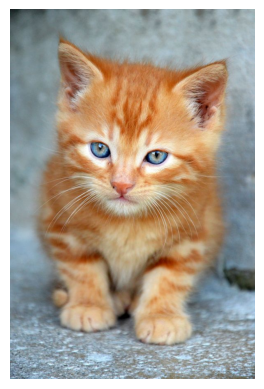

In [158]:
img = Image.open("220153_K-Means-Clustering/dataset/standard_image.jpeg")

img = np.array(img)

plt.imshow(img)
plt.axis("off")
plt.show()

In [159]:
pixels = img.reshape(-1,3)

print(pixels.shape)

(536400, 3)


In [160]:
wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(pixels)

    wcss.append(kmeans.inertia_)

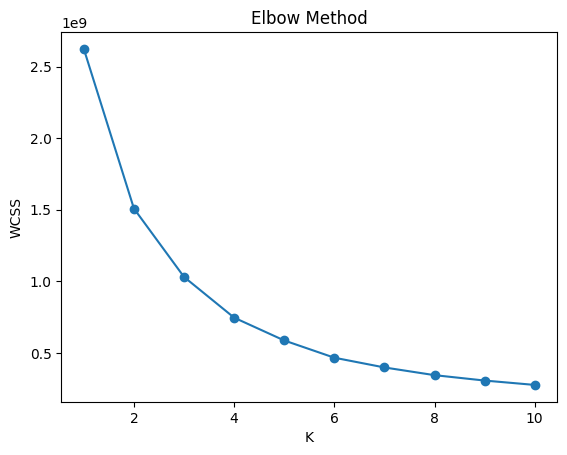

In [161]:
plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [162]:
k = 8

model = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

model.fit(pixels)

KMeans(n_init=10, random_state=42)

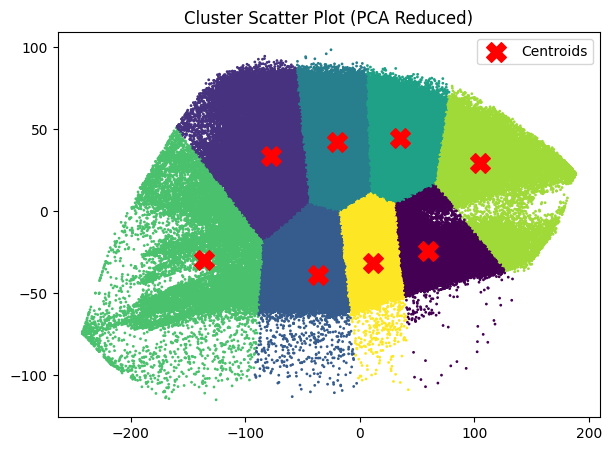

In [163]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pixels_2d = pca.fit_transform(pixels)

centroids_2d = pca.transform(model.cluster_centers_)

plt.figure(figsize=(7,5))

plt.scatter(
    pixels_2d[:,0],
    pixels_2d[:,1],
    c=labels,
    cmap='viridis',
    s=1
)

plt.scatter(
    centroids_2d[:,0],
    centroids_2d[:,1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.title("Cluster Scatter Plot (PCA Reduced)")
plt.legend()
plt.show()

## Cluster Interpretation

Cluster 0 represents darker pixel regions with low intensity values, likely background areas.

Cluster 1 represents medium intensity colors, representing mixed regions.

Cluster 2 represents bright pixel regions, likely foreground objects.

In [164]:
labels = model.predict(pixels)

centers = model.cluster_centers_

compressed = centers[labels]

compressed = compressed.reshape(img.shape)

compressed = compressed.astype(np.uint8)

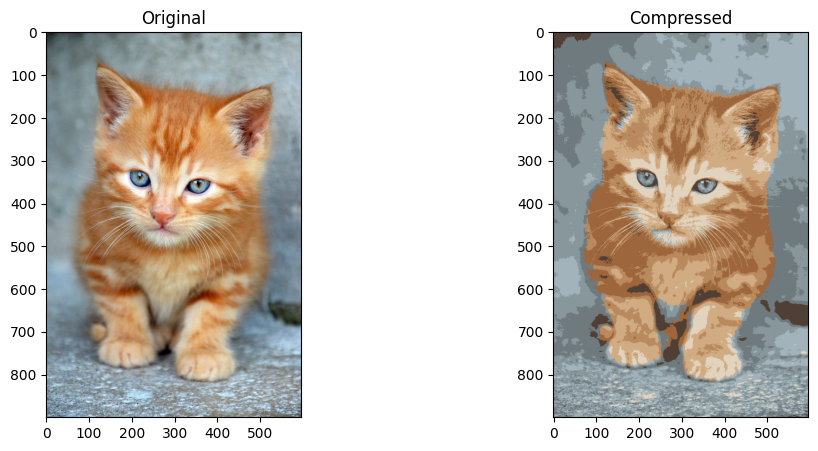

In [165]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(compressed)
plt.title("Compressed")

plt.show()

In [166]:
my_img = Image.open(
    "220153_K-Means-Clustering/dataset/custom_image.jpeg"
)

my_img = np.array(my_img)

In [167]:
custom_pixels = my_img.reshape(-1, 3)

custom_labels = model.predict(custom_pixels)

df_custom = pd.DataFrame(custom_pixels, columns=["R","G","B"])
df_custom["Cluster_ID"] = custom_labels

df_custom.head(10)

,R,G,B,Cluster_ID
0,132,112,75,1
1,180,161,129,4
2,205,189,166,4
3,203,189,176,6
4,210,201,196,6
5,217,212,209,6
6,222,216,216,6
7,229,225,224,6
8,222,221,217,6
9,222,221,217,6


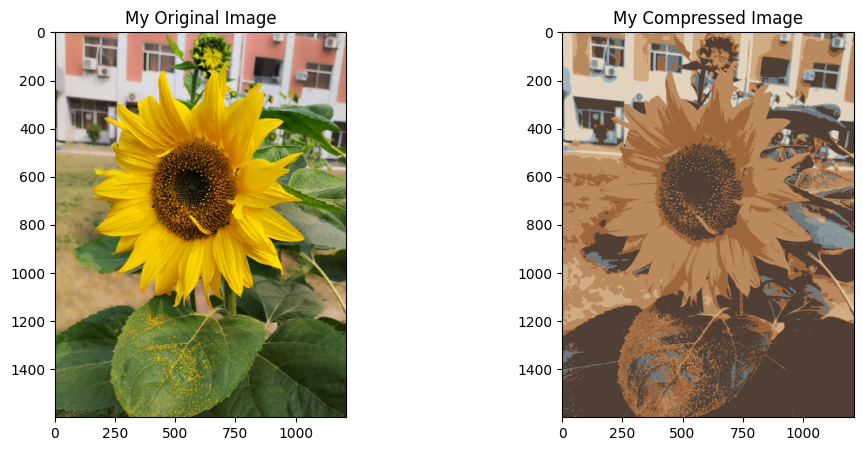

In [168]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(my_img)
plt.title("My Original Image")

plt.subplot(1,2,2)
plt.imshow(my_compressed)
plt.title("My Compressed Image")

plt.show()

In [169]:
import joblib

joblib.dump(
    model,
    "kmeans_image_model.pkl"
)

['kmeans_image_model.pkl']